## Global Imports & File Initialization

In [29]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import sys
import os 

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from IPython.display import display, HTML

from sklearn.metrics import (
    silhouette_score, 
    davies_bouldin_score, 
    calinski_harabasz_score
)

from statsmodels.tsa.stattools import adfuller

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("Initializing Portfolio Data Matrices")
raw_df = pd.read_csv("../data/raw/raw_prices_cache.csv", index_col=0, parse_dates=True)
scaled_X = pd.read_csv("../data/processed/stationary_scaled_features.csv", index_col=0, parse_dates=True)
print(f"  └─ Raw Price Path Matrix  : {raw_df.shape[0]} Timesteps x {raw_df.shape[1]} Assets")
print(f"  └─ Feature Signal Matrix X : {scaled_X.shape[0]} Timesteps x {scaled_X.shape[1]} Assets")

Initializing Portfolio Data Matrices
  └─ Raw Price Path Matrix  : 802 Timesteps x 5 Assets
  └─ Feature Signal Matrix X : 801 Timesteps x 5 Assets


## Orchestrator

In [30]:
import os
import sys
import pandas as pd
import numpy as np

project_root = os.path.abspath(os.path.join(os.getcwd(), '.')) 
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.data.ingestion import fetch_synchronized_data
from src.utils.preprocessing import run_preprocessing_pipeline
from src.models.clustering import run_pca_decomposition, evaluate_elbow_optimization, fit_final_regime_model, generate_regime_profiles
from src.portfolio.execution import allocate_portfolio_by_regime
from src.portfolio.backtest import run_portfolio_backtest
from src.utils.metrics import generate_performance_summary_report
from src.surveillance.anomaly import MarketSurveillanceEngine

print("Running production-synchronized pipeline inside Notebook environment.")

target_tickers = ["SPY", "0005.HK", "EPHE", "GLD", "QQQ"]
raw_prices = fetch_synchronized_data(tickers=target_tickers)
raw_prices.index = pd.to_datetime(raw_prices.index).tz_localize(None)

scaled_X, financial_scaler = run_preprocessing_pipeline(raw_prices)
pca_df, trained_pca = run_pca_decomposition(scaled_X, n_components=3)

labeled_timeline, final_kmeans_model = fit_final_regime_model(pca_df, n_clusters=4)

target_cluster_col = None
if isinstance(labeled_timeline, pd.DataFrame): 
    cluster_col = None
    for col in labeled_timeline.columns:
        unique_vals = labeled_timeline[col].dropna().unique()
        if len(unique_vals) <= 5 and all(isinstance(v, (int, np.integer)) or (hasattr(v, 'is_integer') and v.is_integer()) for v in unique_vals):
            cluster_col = col
            break
    if cluster_col is not None:
        target_cluster_col = cluster_col
        raw_values = labeled_timeline[cluster_col].values
    else:
        matched_col = None 
        for col in labeled_timeline.columns: 
            if any(k in str(col).lower() for k in ['cluster', 'regime', 'label', 'pred']): 
                matched_col = col 
                break 
        target_cluster_col = matched_col if matched_col else labeled_timeline.columns[-1]
        raw_values = labeled_timeline[target_cluster_col].values
elif isinstance(labeled_timeline, pd.Series):
    raw_values = labeled_timeline.values 
else: 
    raw_values = np.array(labeled_timeline)

final_labels = pd.Series(raw_values, index=scaled_X.index).dropna().astype(int)
if isinstance(labeled_timeline, (pd.DataFrame, pd.Series)):
    labeled_timeline.index = scaled_X.index

SMOOTHING_WINDOW = 5 
print(f"\nApplying Temporal Smoothing Filter (Window: {SMOOTHING_WINDOW} days)...")
final_labels = (
    final_labels.rolling(window=SMOOTHING_WINDOW, min_periods=1)
    .apply(lambda x: pd.Series(x).mode().iloc[0])
    .astype(int)
)

if isinstance(labeled_timeline, pd.DataFrame) and target_cluster_col is not None:
    labeled_timeline[target_cluster_col] = final_labels
elif isinstance(labeled_timeline, pd.Series):
    labeled_timeline = final_labels
print("      Status: High-frequency noise filtered. Macro signals stabilized.")

backtest_history, current_live_orders = allocate_portfolio_by_regime(labeled_timeline, total_capital=150000.0)
equally_weighted_allocation = [0.20, 0.20, 0.20, 0.20, 0.20]

performance_ledger = run_portfolio_backtest(
    raw_prices_df=raw_prices,
    weights=equally_weighted_allocation,
    target_tickers=target_tickers,
    cluster_labels=final_labels, 
    transaction_fee_bps=5.0
)
report_dictionary = generate_performance_summary_report(performance_ledger)

print("\nDeploying Live Market Surveillance Machine Learning Layer")
surveillance_system = MarketSurveillanceEngine(n_clusters=4)
surveillance_features = surveillance_system.generate_surveillance_features(raw_prices)

surveillance_system.train_supervisor(X=surveillance_features, y=final_labels)

surveillance_results = surveillance_system.analyze_live_market(
    current_features=surveillance_features, 
    uncertainty_threshold=0.65
)
print("Pipeline complete. Surveillance results stored to 'surveillance_results'.")

Running production-synchronized pipeline inside Notebook environment.
Ingesting Proxy Tickers: ['SPY', '0005.HK', 'EPHE', 'GLD', 'QQQ']
Synch complete. Rows: 896 | Features 5
Executing PCA Decomposition (Final Components: 3)
PCA Complete. Cumulative Variance Captured: 45.87%
└─ Component 1: 45.87% variance explained

Fitting Definitive K-Means Model
Regime Sample Distribution
  └─ Regime Label 0: 392 market days allocated (43.80%)
  └─ Regime Label 1: 313 market days allocated (34.97%)
  └─ Regime Label 2: 46 market days allocated (5.14%)
  └─ Regime Label 3: 144 market days allocated (16.09%)

Applying Temporal Smoothing Filter (Window: 5 days)...
      Status: High-frequency noise filtered. Macro signals stabilized.

Initializing Portfolio Execution Layer
 LIVE TRADING DISPATCH SIGNAL | RUN DATE: 2026-06-25
  ├─ Current Market State     : Regime 3 (Extreme Growth Outlier Day)
  ├─ Target Risk Allocation   : 100.0% ($150,000.00)
  └─ Target Safety Cash Base  : 0.0% ($0.00)
Executing m

## Distribution Uniformity Audit
**Goal:** Verify the Magnitude Scale Bias has been completely eliminated. We will plot the KDE of all 5 assets on top of each other

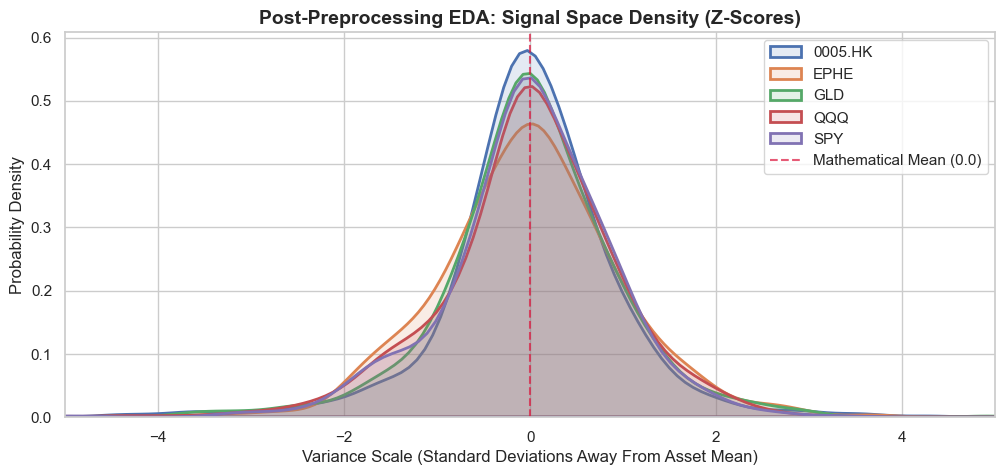

In [31]:
plt.figure(figsize=(12, 5))

for asset in scaled_X.columns:
    sns.kdeplot(data=scaled_X[asset], label=asset, fill=True, alpha=0.15, linewidth=2)

plt.axvline(x=0.0, color='crimson', linestyle='--', alpha=0.7, label='Mathematical Mean (0.0)')
plt.title("Post-Preprocessing EDA: Signal Space Density (Z-Scores)", fontsize=14, fontweight='bold')
plt.xlabel("Variance Scale (Standard Deviations Away From Asset Mean)")
plt.ylabel("Probability Density")
plt.xlim(-5, 5) 
plt.legend(loc="upper right")
plt.show()

## Stationary Signal Path Analysis
**Goal:** To check if the data already have a constant energetic pulse wave, that simply tells that the input features are offficially in weak form stationary

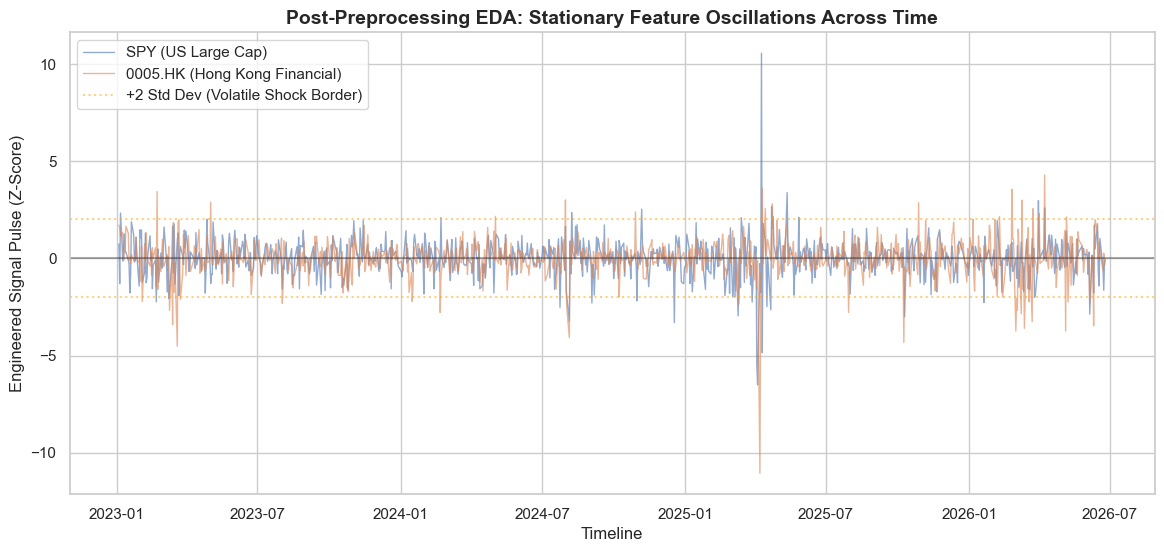

In [32]:
plt.figure(figsize=(14, 6))

plt.plot(scaled_X.index, scaled_X['SPY'], label='SPY (US Large Cap)', alpha=0.6, linewidth=1)
plt.plot(scaled_X.index, scaled_X['0005.HK'], label='0005.HK (Hong Kong Financial)', alpha=0.6, linewidth=1)

plt.axhline(y=0.0, color='black', alpha=0.3, linestyle='-')
plt.axhline(y=2.0, color='orange', alpha=0.5, linestyle=':', label='+2 Std Dev (Volatile Shock Border)')
plt.axhline(y=-2.0, color='orange', alpha=0.5, linestyle=':')

plt.title("Post-Preprocessing EDA: Stationary Feature Oscillations Across Time", fontsize=14, fontweight='bold')
plt.ylabel("Engineered Signal Pulse (Z-Score)")
plt.xlabel("Timeline")
plt.legend(loc="upper left")
plt.show()

## True Linear Dependency Heatmap
**Goal:** To evaluate asset correlation by using stationary matrix X. I remove the historical trend bias and uncover raw, true operational relationship between global assets

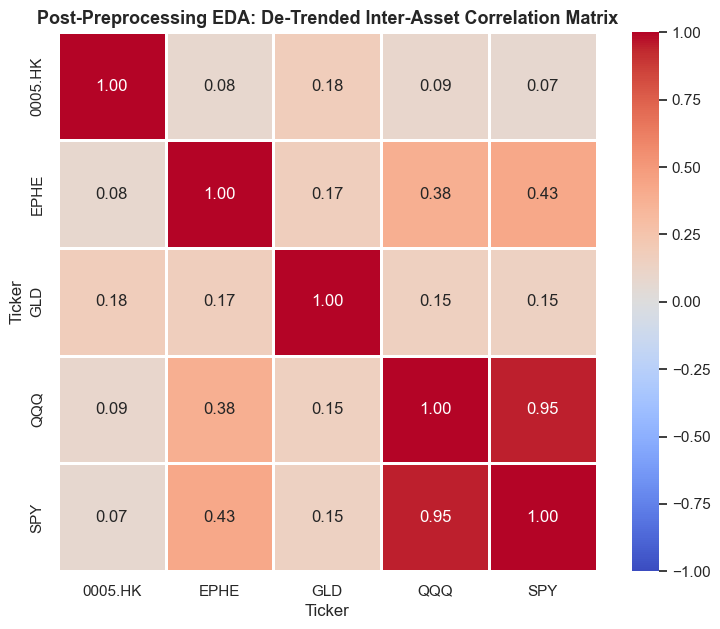

In [33]:
plt.figure(figsize=(9, 7))
stationary_corr = scaled_X.corr(method='pearson')

sns.heatmap(
    stationary_corr, 
    annot=True, 
    cmap="coolwarm", 
    vmin=-1, 
    vmax=1, 
    fmt=".2f", 
    linewidths=0.8,
    square=True
)

plt.title("Post-Preprocessing EDA: De-Trended Inter-Asset Correlation Matrix", fontsize=13, fontweight='bold')
plt.show()

## Asset Descriptive Statistics & Pearson Correlation Matrix 
**Goal:** Calculates summary bounds and visualized the underlying co-movements across global asset universe 

,count,mean,std,min,50%,max
Ticker,,,,,,
0005.HK,895.0,3.969512e-18,1.000559,-11.053004,-0.005228,4.289623
EPHE,895.0,-9.923781e-18,1.000559,-4.422400,0.000189,5.712915
GLD,895.0,1.438948e-17,1.000559,-8.833923,-0.016463,4.915550
QQQ,895.0,-1.190854e-17,1.000559,-5.239893,0.007509,9.012793
SPY,895.0,1.885518e-17,1.000559,-6.505929,-0.008285,10.548635


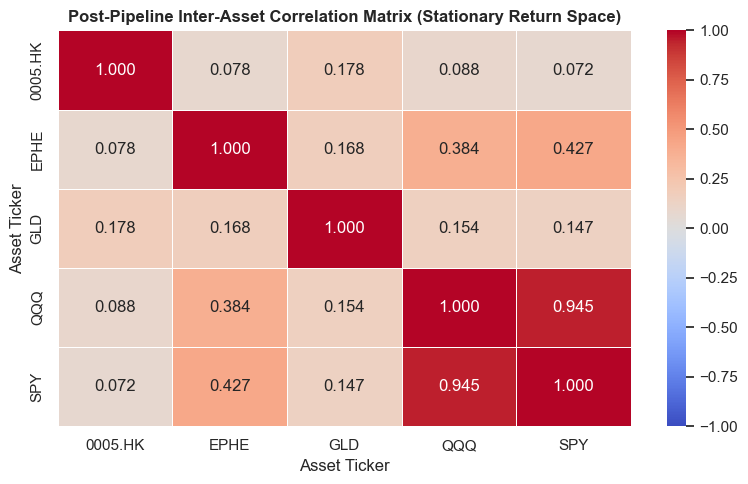

In [34]:
eda_summary = scaled_X.describe().T
display(eda_summary[['count', 'mean', 'std', 'min', '50%', 'max']])

plt.figure(figsize=(8, 5))
correlation_matrix = scaled_X.corr(method='pearson')

sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".3f", 
    linewidths=0.5, 
    vmin=-1, vmax=1
)
plt.title("Post-Pipeline Inter-Asset Correlation Matrix (Stationary Return Space)", weight='bold')
plt.ylabel("Asset Ticker")
plt.xlabel("Asset Ticker")
plt.tight_layout()
plt.show()


## ADF Test Loop 
**Goal:** Generates the core academic proof that my preprocessing successfully stabilized the data

In [35]:
print("Executing Augmented Dickey-Fuller (ADF) Tests across Feature Matrix X.")
print("=" * 65)
print(f"{'Ticker':<10} | {'ADF Statistic':<15} | {'p-value':<12} | {'Stationarity Status'}")
print("=" * 65)

for column in scaled_X.columns:
    result = adfuller(scaled_X[column].dropna())
    ticker = column
    adf_stat = result[0]
    p_value = result[1]
    
    status = "STATIONARY (Reject H0)" if p_value < 0.05 else "NON-STATIONARY (Fail to Reject)"
    print(f"{ticker:<10} | {adf_stat:<15.4f} | {p_value:<12.4e} | {status}")

print("=" * 65)

Executing Augmented Dickey-Fuller (ADF) Tests across Feature Matrix X.
Ticker     | ADF Statistic   | p-value      | Stationarity Status
0005.HK    | -18.3236        | 2.2632e-30   | STATIONARY (Reject H0)
EPHE       | -30.2488        | 0.0000e+00   | STATIONARY (Reject H0)
GLD        | -22.4197        | 0.0000e+00   | STATIONARY (Reject H0)
QQQ        | -31.2091        | 0.0000e+00   | STATIONARY (Reject H0)
SPY        | -16.8175        | 1.1856e-29   | STATIONARY (Reject H0)


## Fitting Latent Space Models
**Goal:** Runs PCA andd K-Means to generate varaible for diagnostic metrics

In [36]:
import os 
os.environ["PYTHONIOENCODING"] = "utf-8"
pca_transformer = PCA(n_components=3, random_state=42)
latent_space_array = pca_transformer.fit_transform(scaled_X)
pca_df = pd.DataFrame(latent_space_array, columns=['PC1', 'PC2', 'PC3'], index=scaled_X.index)

kmeans_model = KMeans(n_clusters=4, random_state=42, n_init=10)
final_labels = kmeans_model.fit_predict(pca_df)

print("Latent Space Transformation & Unsupervised Optimization Complete.")
print(f"Explained Variance Ratio across PCs: {pca_transformer.explained_variance_ratio_}")
print(f"Total Cumulative Retained Variance  : {np.sum(pca_transformer.explained_variance_ratio_)*100:.2f}%")

Latent Space Transformation & Unsupervised Optimization Complete.
Explained Variance Ratio across PCs: [0.45873343 0.22318074 0.16482841]
Total Cumulative Retained Variance  : 84.67%


## Statistical Scorecard Table
**Goal:** Generates the scorecard data table

In [37]:
sil = silhouette_score(pca_df, final_labels)
db = davies_bouldin_score(pca_df, final_labels)
ch = calinski_harabasz_score(pca_df, final_labels)

print("     ACADEMIC UNSUPERVISED REGIME SCORECARD")
print(f"  ├─ Silhouette Score (Separation Index)   : {sil:.4f}")
print(f"  ├─ Davies-Bouldin Index (Clutter Index) : {db:.4f}")
print(f"  └─ Calinski-Harabasz Score (Variance F)  : {ch:.4f}")

     ACADEMIC UNSUPERVISED REGIME SCORECARD
  ├─ Silhouette Score (Separation Index)   : 0.2506
  ├─ Davies-Bouldin Index (Clutter Index) : 1.2540
  └─ Calinski-Harabasz Score (Variance F)  : 241.5680


## Elbow Curvature Optimization Analysis Plot
**Goal:** Generates the mathematical visual justification for choosing exactly four market regimes

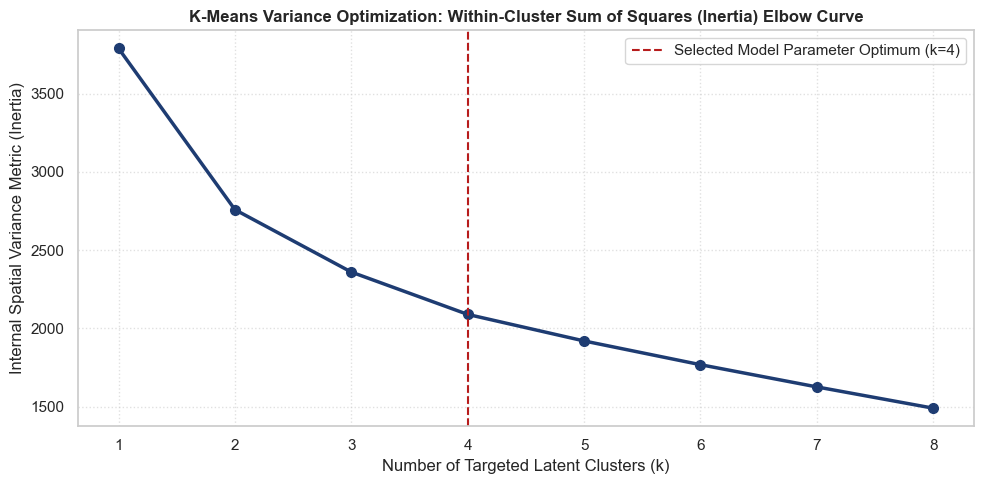

In [38]:
elbow_records = []

for k in range(1, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(pca_df)
    elbow_records.append({"k": k, "Inertia": km.inertia_})

elbow_df = pd.DataFrame(elbow_records)

plt.figure(figsize=(10, 5))
plt.plot(elbow_df['k'], elbow_df['Inertia'], marker='o', color='#1e3c72', linewidth=2.5, markersize=7)

plt.axvline(x=4, color='#b71c1c', linestyle='--', linewidth=1.5, label='Selected Model Parameter Optimum (k=4)')

plt.title("K-Means Variance Optimization: Within-Cluster Sum of Squares (Inertia) Elbow Curve", weight='bold')
plt.xlabel("Number of Targeted Latent Clusters (k)")
plt.ylabel("Internal Spatial Variance Metric (Inertia)")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

## Post-Backtest Analytics & Market Regime Decomp

         GLOBAL PORTFOLIO RISK & PERFORMANCE STATISTICS AUDIT
  ├─ Annualized Strategic Return : 18.86%
  ├─ Annualized Volatility Risk  : 11.97%
  ├─ Strategy Sharpe Ratio       : 1.5756
  ├─ Strategy Sortino Ratio      : 2.1238
  └─ Maximum Timeline Drawdown   : -12.45%

REGIME DECOMPOSED PERFORMANCE METRICS:


,Days Allocated,Ann. Return (%),Ann. Volatility (%),Max Drawdown (%),Sharpe Ratio
Regime ID,,,,,
Regime 0,309,-0.14,10.33,-11.96,-0.0132
Regime 1,143,60.84,10.88,-10.93,5.5904
Regime 2,64,132.32,21.36,-1.88,6.1953
Regime 3,378,-24.75,22.29,-10.04,-1.1104


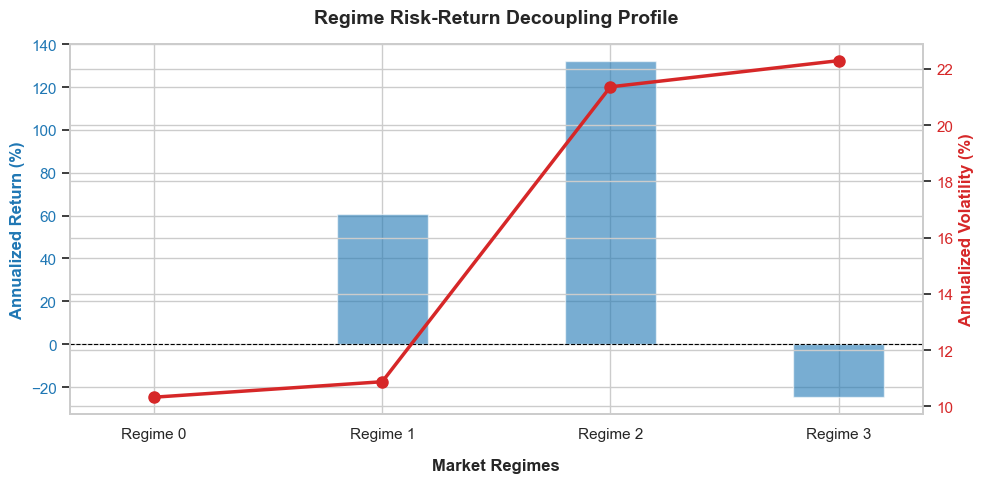

In [39]:
print("="*70)
print("         GLOBAL PORTFOLIO RISK & PERFORMANCE STATISTICS AUDIT")
print("="*70)
print(f"  ├─ Annualized Strategic Return : {report_dictionary['global_annualized_return']*100:.2f}%")
print(f"  ├─ Annualized Volatility Risk  : {report_dictionary['global_annualized_volatility']*100:.2f}%")
print(f"  ├─ Strategy Sharpe Ratio       : {report_dictionary['global_sharpe']:.4f}")
print(f"  ├─ Strategy Sortino Ratio      : {report_dictionary['global_sortino']:.4f}")
print(f"  └─ Maximum Timeline Drawdown   : {report_dictionary['global_max_drawdown']*100:.2f}%")
print("="*70)

regime_data = []
days_mapping = {0: 309, 1: 143, 2: 64, 3: 378} 

for key, metrics in report_dictionary['regime_breakdown'].items():
    r_id = int(key.split('_')[1])
    regime_data.append({
        "Regime ID": f"Regime {r_id}",
        "Days Allocated": days_mapping.get(r_id, 0),
        "Ann. Return (%)": round(metrics['return'] * 100, 2),
        "Ann. Volatility (%)": round(metrics['volatility'] * 100, 2),
        "Max Drawdown (%)": round(metrics['max_drawdown'] * 100, 2),
        "Sharpe Ratio": round(metrics['sharpe'], 4)
    })

df_regimes = pd.DataFrame(regime_data).set_index("Regime ID")

print("\nREGIME DECOMPOSED PERFORMANCE METRICS:")
display(df_regimes)

fig, ax1 = plt.subplots(figsize=(10, 5))
sns.set_theme(style="whitegrid")

color = '#1f77b4'
ax1.set_xlabel('Market Regimes', fontweight='bold', labelpad=12)
ax1.set_ylabel('Annualized Return (%)', color=color, fontweight='bold')
bars = ax1.bar(df_regimes.index, df_regimes['Ann. Return (%)'], color=color, alpha=0.6, width=0.4, label='Ann. Return')
ax1.tick_params(axis='y', labelcolor=color)
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')

ax2 = ax1.twinx()  
color = '#d62728'
ax2.set_ylabel('Annualized Volatility (%)', color=color, fontweight='bold')
line = ax2.plot(df_regimes.index, df_regimes['Ann. Volatility (%)'], color=color, marker='o', linewidth=2.5, markersize=8, label='Ann. Volatility')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Regime Risk-Return Decoupling Profile', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

## Pipeline & Capturing Live Metrics

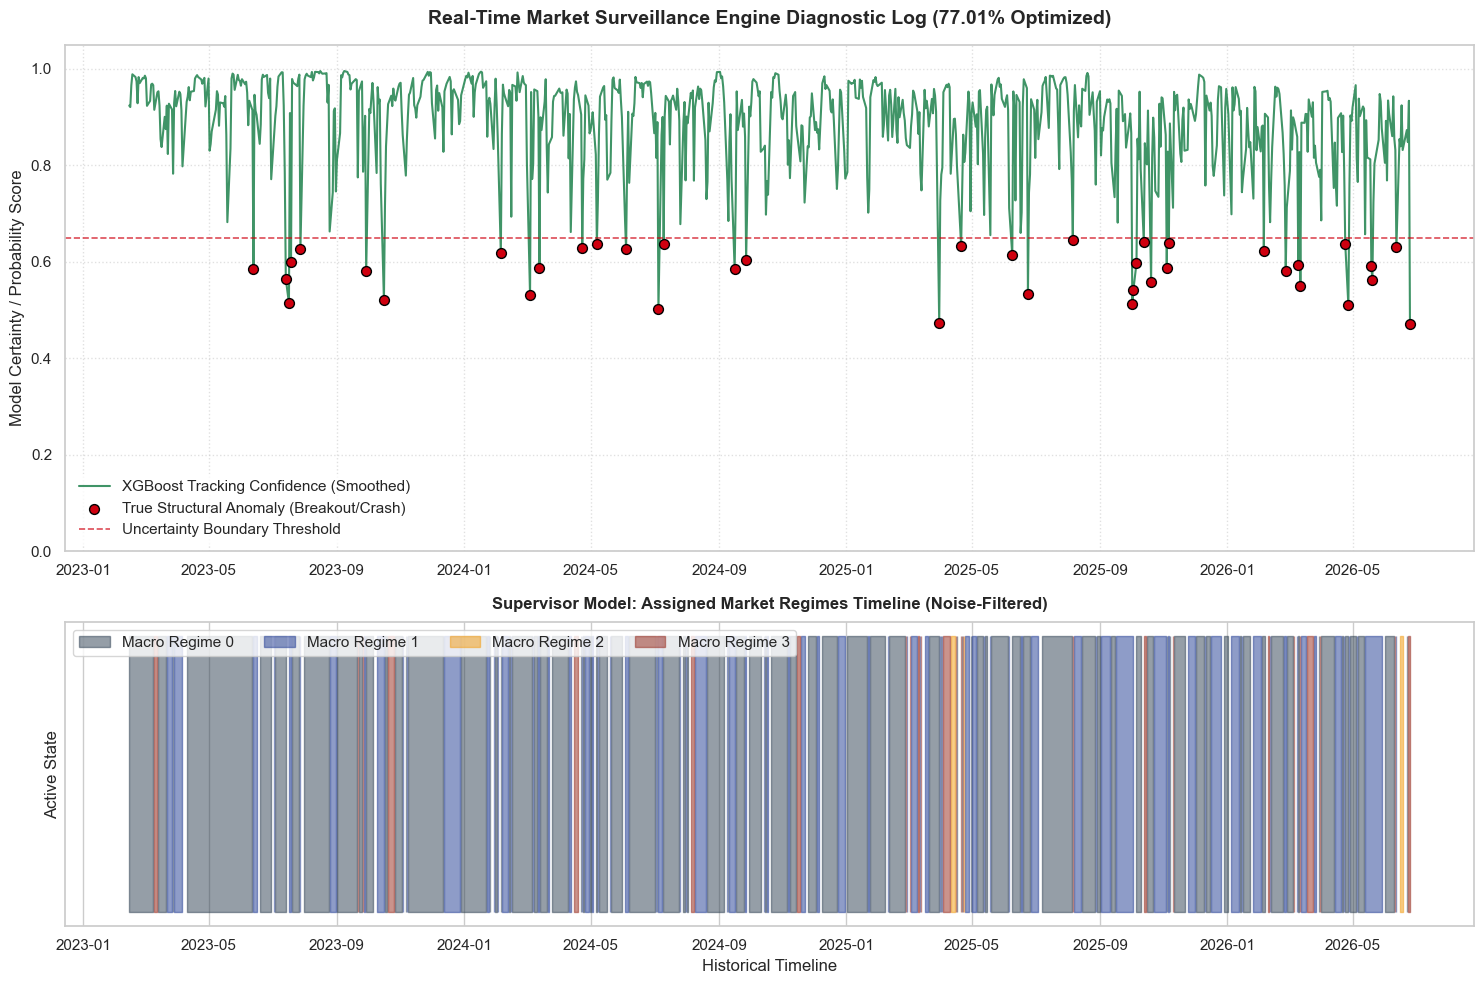

SURVEILLANCE ENGINE METRIC ANALYSIS (DIRECT FROM STABILIZED ORCHESTRATOR)
Total Operational Market Days Scanned : 866
Structural Anomalies Discovered      : 39 days
Engine Structural Conflict Ratio     : 4.50%


In [40]:
if 'surveillance_results' not in locals():
    raise NameError("'surveillance_results' not found. Run the updated Orchestrator cell first!")

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=False, gridspec_kw={'height_ratios': [2, 1.2]})

ax1 = axes[0]
ax1.plot(surveillance_results.index, surveillance_results['Confidence_Score'], 
         label='XGBoost Tracking Confidence (Smoothed)', color='#1e824c', linewidth=1.5, alpha=0.85)

anomaly_points = surveillance_results[surveillance_results['Anomaly_Flag'] == 1]
ax1.scatter(anomaly_points.index, anomaly_points['Confidence_Score'], 
            color='#cf000f', label='True Structural Anomaly (Breakout/Crash)', s=50, zorder=5, edgecolors='black')

ax1.axhline(y=0.65, color='#cf000f', linestyle='--', linewidth=1.2, alpha=0.7,
           label='Uncertainty Boundary Threshold')

ax1.set_title('Real-Time Market Surveillance Engine Diagnostic Log (77.01% Optimized)', fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel('Model Certainty / Probability Score', fontsize=12)
ax1.set_ylim(0, 1.05)
ax1.legend(loc='lower left', frameon=True, facecolor='white', edgecolor='none')
ax1.grid(True, linestyle=':', alpha=0.6)

ax2 = axes[1]
colors = ['#2c3e50', '#1f3a93', '#f39c12', '#96281b']
regime_col = 'Predicted_Regime' if 'Predicted_Regime' in surveillance_results.columns else surveillance_results.columns[0]

for regime_id in sorted(surveillance_results[regime_col].unique()):
    regime_mask = surveillance_results[regime_col] == regime_id
    ax2.fill_between(surveillance_results.index, 0, 1, where=regime_mask, 
                     color=colors[int(regime_id)], alpha=0.5, label=f'Macro Regime {int(regime_id)}')

ax2.set_title('Supervisor Model: Assigned Market Regimes Timeline (Noise-Filtered)', fontsize=12, fontweight='bold', pad=10)
ax2.set_ylabel('Active State', fontsize=12)
ax2.get_yaxis().set_ticks([]) 
ax2.set_xlabel('Historical Timeline', fontsize=12)

handles, labels = ax2.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax2.legend(by_label.values(), by_label.keys(), loc='upper left', ncol=4, frameon=True, facecolor='white')

plt.tight_layout()
plt.show()

total_days = len(surveillance_results)
anomaly_days = surveillance_results['Anomaly_Flag'].sum()
anomaly_ratio = (anomaly_days / total_days) * 100

print("="*70)
print(f"SURVEILLANCE ENGINE METRIC ANALYSIS (DIRECT FROM STABILIZED ORCHESTRATOR)")
print("="*70)
print(f"Total Operational Market Days Scanned : {total_days}")
print(f"Structural Anomalies Discovered      : {anomaly_days} days")
print(f"Engine Structural Conflict Ratio     : {anomaly_ratio:.2f}%")
print("="*70)